# Figure 2 of grokking paper

todo: can we make the curves on each other? requires tuning of the parameter! 

In [1]:
# 2(c). Sweep over laziness.
# Figure 2. Modular arithmetic.

import jax
import jax.numpy as jnp
import flax.linen as nn
import numpy as np
from flax.training import train_state
import optax
from tqdm import tqdm
import matplotlib.pyplot as plt
from jax import random


In [2]:
p = 23
D = 2 * p  # Input units (each input is a pair of one-hot vectors)
alpha = 0.9  # Fraction of data used for training
scale = 1
seed = 1
N = 100


scales = [1]

class SimpleMLP(nn.Module):
    input_dim: int
    hidden_dim: int
    output_dim: int
    scale: float = 1

    def setup(self):
        self.layer1 = nn.Dense(self.hidden_dim, kernel_init=random.normal, use_bias=False)
        self.layer2 = nn.Dense(self.output_dim, kernel_init=random.normal, use_bias=False)

    def __call__(self, x):
        x = self.layer1(x)
        x = x ** 2  # Quadratic activation
        x = self.layer2(x) * self.scale / (self.input_dim * self.hidden_dim)
        return x * scale

def modulo(x):
    a, b = jnp.where(x == 1)[0]
    b -= p
    m = (a + b) % p
    return jax.nn.one_hot(m, p)

# Create dataset for modular arithmetic task
# Each input is a pair of one-hot vectors; each output is a one-hot vector
X = jnp.array([jnp.concatenate([jax.nn.one_hot(i // p, p), jax.nn.one_hot(i % p, p)]) for i in range(p ** 2)])
y = jnp.array([modulo(x) for x in X])
key = jax.random.PRNGKey(seed)
indices = jax.random.permutation(key, p ** 2)
train_indices = indices[:int(alpha * (p ** 2))]
test_indices = indices[int(alpha * (p ** 2)):]
X_train, y_train = X[train_indices], y[train_indices]
X_test, y_test = X[test_indices], y[test_indices]

In [3]:
X_train.shape

(476, 46)

In [4]:
epochs = 1000
scales = [0.5, 1, 1.5, 2]
# scales = [2]

lambdas = [7e-2, 2.5e-2/2, 1e-2/2, 5e-3/2]
trs_precond, tls_precond = [], []
tr_losses_precond, te_losses_precond = [], []
for i, scale in enumerate(scales):
    lr = 1e2 / scale ** 2
    print(f"Grokking modular addition: p: {p}, D: {D}, train-set-frac: {alpha}, scale: {scale}, lr: {round(lr, 2)}, seed: {seed}, N: {N}, epochs: {epochs}")

    model = SimpleMLP(D, N, p, scale)
    params = model.init(key, X_train)

    tx = optax.sgd(learning_rate=lr)
    # tx = optax.chain(
    #        optax.sgd(learning_rate=lr),
    #        optax.scale_by_backtracking_linesearch(max_backtracking_steps=15)
    # )
    
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

    @jax.jit
    def loss_fn(params, X, y):
        y_pred = state.apply_fn(params, X)
        loss = jnp.mean((y_pred - y) ** 2) / float(scale ** 2)
        return loss
        
    grad_fn = jax.value_and_grad(loss_fn)      
    @jax.jit
    def train_step(state, X, y):
        loss, grads = grad_fn(state.params, X, y)

        # if precond == 'smw':
        # TODO: change alpha to match Variance as suggested by Alexey
        lamb = min((5e-2, 0.025 / scale ** 2))
        lamb = 2e-2 / scale ** 2
        lamb = lambdas[i]
        print(f'Running SMW {lamb=}')
        

        _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, X), (state.params,), (grads,))
        jacobian_fn = jax.jacrev(
            lambda params, x: state.apply_fn(params, x)
        )(state.params, X)
        flat_jacobian = []
        for layer in jacobian_fn['params'].values():
            for param in layer.values():
                flat_jacobian.append(param.reshape(476, -1))
        jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
        mat = jacobian_fn @ jacobian_fn.T

        out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
        _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, X)
        adjustment = vjp_fn(out)[0] 
        grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)
        
        state = state.apply_gradients(grads=grads)
        return state, loss

    @jax.jit
    def eval_step(params, X, y):
        y_pred = state.apply_fn(params, X)
        loss = jnp.mean((y_pred - y) ** 2)

        predicted_test = jnp.argmax(y_pred, axis=1)
        correct_test = jnp.sum(predicted_test == jnp.argmax(y, axis=1))

        return loss, correct_test

    @jax.jit
    def eval_train(params, X, y):
        y_pred_train = state.apply_fn(params, X)
        predicted_train = jnp.argmax(y_pred_train, axis=1)
        correct_train = jnp.sum(predicted_train == jnp.argmax(y, axis=1))
        return correct_train

    train_loss, test_loss = [], []
    train_acc, test_acc = [], []
    for epoch in tqdm(range(epochs)):
        state, loss = train_step(state, X_train, y_train)
        train_loss.append(loss.item())

        # Evaluation of model
        correct_train = eval_train(state.params, X_train, y_train)
        train_acc.append(100 * correct_train / len(y_train))

        test_loss_batch, correct_test = eval_step(state.params, X_test, y_test)
        test_loss.append(test_loss_batch)
        test_acc.append(100 * correct_test / len(y_test))
        
        # (f"Epoch {epoch + 1}/{epochs} - Train Accuracy: {train_acc[-1]:.2f}, Test Accuracy: {test_acc[-1]:.2f}")
        
    trs_precond += [train_acc]
    tls_precond += [test_acc]

    tr_losses_precond += [train_loss]
    te_losses_precond += [test_loss]

Grokking modular addition: p: 23, D: 46, train-set-frac: 0.9, scale: 0.5, lr: 400.0, seed: 1, N: 100, epochs: 1000


  0%|                                                                                                                                                          | 0/1000 [00:00<?, ?it/s]

Running SMW lamb=0.07


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:15<00:00, 63.94it/s]


Grokking modular addition: p: 23, D: 46, train-set-frac: 0.9, scale: 1, lr: 100.0, seed: 1, N: 100, epochs: 1000


...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 81.03it/s]


Grokking modular addition: p: 23, D: 46, train-set-frac: 0.9, scale: 2, lr: 25.0, seed: 1, N: 100, epochs: 1000


  0%|                                                                                                                                                          | 0/1000 [00:00<?, ?it/s]

Running SMW lamb=0.0025


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 80.98it/s]


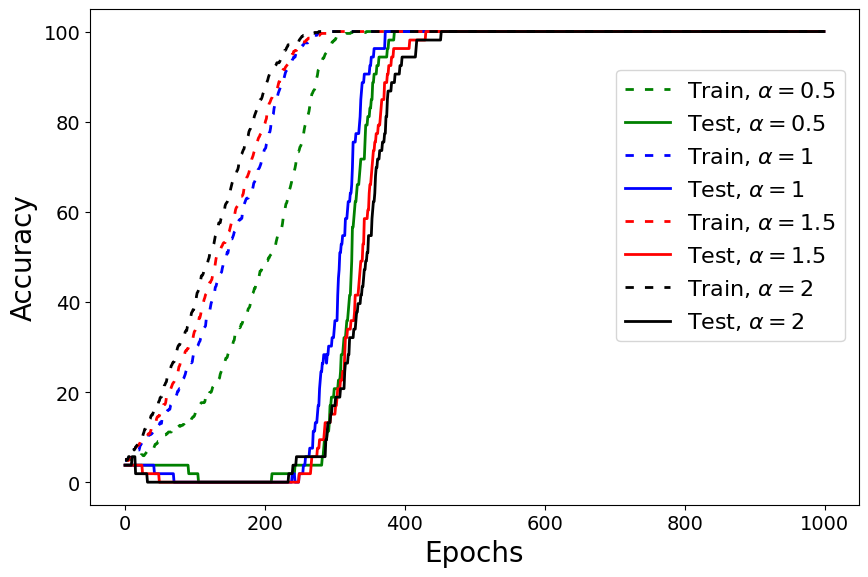

In [5]:
colors = ['g', 'b', 'r', 'black']
plt.figure(figsize=(9, 6))
plt.rcParams.update({'font.size': 14})

plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)

for i in range(len(trs_precond)):
    plt.plot(range(len(trs_precond[i])), trs_precond[i], color=colors[i], label=rf'Train, $\alpha={scales[i]}$', linestyle='--', linewidth=2.0, dashes=(3, 4))
    plt.plot(range(len(trs_precond[i])), tls_precond[i], color=colors[i], label=rf'Test, $\alpha={scales[i]}$', linewidth=2.0)

plt.legend(bbox_to_anchor=(0.67, 0.9), fontsize=16)
plt.tight_layout()
plt.show()

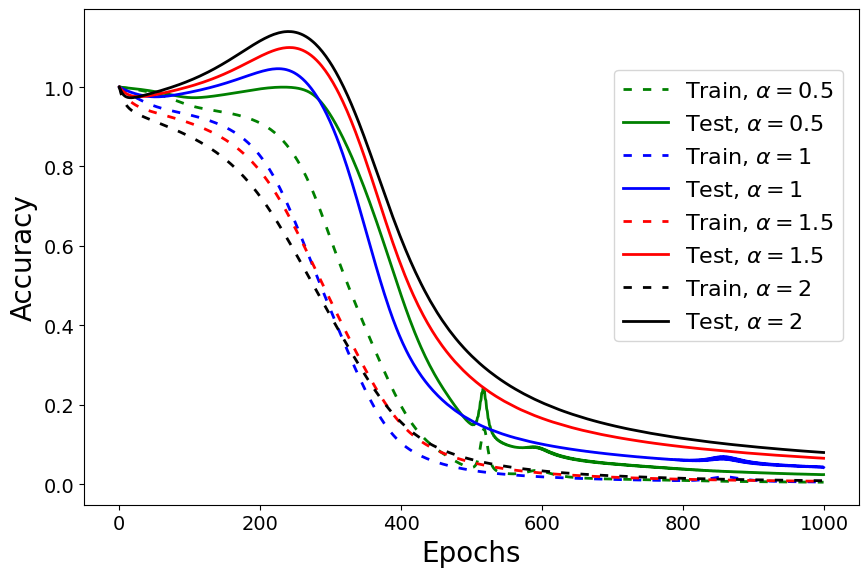

In [6]:
colors = ['g', 'b', 'r', 'black']
plt.figure(figsize=(9, 6))
plt.rcParams.update({'font.size': 14})

plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)

for i in range(len(trs_precond)):
    plt.plot(range(len(trs_precond[i])), np.array(tr_losses_precond[i]) / tr_losses_precond[i][0], color=colors[i], label=rf'Train, $\alpha={scales[i]}$', linestyle='--', linewidth=2.0, dashes=(3, 4))
    plt.plot(range(len(trs_precond[i])), np.array(te_losses_precond[i]) / te_losses_precond[i][0], color=colors[i], label=rf'Test, $\alpha={scales[i]}$', linewidth=2.0)

plt.legend(bbox_to_anchor=(0.67, 0.9), fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
epochs = 100000
scales = [0.5, 1, 1.5, 2]
trs, tls = [], []
tr_losses, te_losses = [], []
for scale in scales:
    lr = 1e2 / scale ** 2
    print(f"Grokking modular addition: p: {p}, D: {D}, train-set-frac: {alpha}, scale: {scale}, lr: {round(lr, 2)}, seed: {seed}, N: {N}, epochs: {epochs}")

    model = SimpleMLP(D, N, p, scale)
    params = model.init(key, X_train)

    tx = optax.sgd(learning_rate=lr)
    # tx = optax.adam(learning_rate=lr) # Tried Adam, but with those learning rates, it doesn't converge
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

    @jax.jit
    def loss_fn(params, X, y):
        y_pred = state.apply_fn(params, X)
        loss = jnp.mean((y_pred - y) ** 2) / float(scale ** 2)
        return loss
        
    grad_fn = jax.value_and_grad(loss_fn)      
    @jax.jit
    def train_step(state, X, y):
        loss, grads = grad_fn(state.params, X, y)

        # if precond == 'smw':
        # TODO: change alpha to match Variance as suggested by Alexey
        # print('Running SMW')
        # lamb = 1e-1 / alpha # THIS IS THE SCALING HERE

        # _, jvp_output = jax.jvp(lambda p: state.apply_fn(p, X), (state.params,), (grads,))
        # jacobian_fn = jax.jacrev(
        #     lambda params, x: state.apply_fn(params, x)
        # )(state.params, X)
        # flat_jacobian = []
        # for layer in jacobian_fn['params'].values():
        #     for param in layer.values():
        #         flat_jacobian.append(param.reshape(476, -1))
        # jacobian_fn = jnp.concatenate(flat_jacobian, axis=1)
        # mat = jacobian_fn @ jacobian_fn.T

        # out = jnp.linalg.solve(jnp.eye(mat.shape[0]) + 1 / lamb * mat, jvp_output / (lamb ** 2))
        # _, vjp_fn = jax.vjp( lambda params, x: state.apply_fn(params, x), state.params, X)
        # adjustment = vjp_fn(out)[0] 
        # grads = jax.tree.map(lambda a, b: 1 / lamb * a - b, grads, adjustment)
        
        state = state.apply_gradients(grads=grads)
        return state, loss

    @jax.jit
    def eval_step(params, X, y):
        y_pred = state.apply_fn(params, X)
        loss = jnp.mean((y_pred - y) ** 2)

        predicted_test = jnp.argmax(y_pred, axis=1)
        correct_test = jnp.sum(predicted_test == jnp.argmax(y, axis=1))

        return loss, correct_test

    @jax.jit
    def eval_train(params, X, y):
        y_pred_train = state.apply_fn(params, X)
        predicted_train = jnp.argmax(y_pred_train, axis=1)
        correct_train = jnp.sum(predicted_train == jnp.argmax(y, axis=1))
        return correct_train

    train_loss, test_loss = [], []
    train_acc, test_acc = [], []
    for epoch in tqdm(range(epochs)):
        state, loss = train_step(state, X_train, y_train)
        train_loss.append(loss.item())

        # Evaluation of model
        correct_train = eval_train(state.params, X_train, y_train)
        train_acc.append(100 * correct_train / len(y_train))

        test_loss_batch, correct_test = eval_step(state.params, X_test, y_test)
        test_loss.append(test_loss_batch)
        test_acc.append(100 * correct_test / len(y_test))

    trs += [train_acc]
    tls += [test_acc]

    tr_losses += [train_loss]
    te_losses += [test_loss]

Grokking modular addition: p: 23, D: 46, train-set-frac: 0.9, scale: 0.5, lr: 400.0, seed: 1, N: 100, epochs: 100000


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:54<00:00, 1818.99it/s]


Grokking modular addition: p: 23, D: 46, train-set-frac: 0.9, scale: 1, lr: 100.0, seed: 1, N: 100, epochs: 100000


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:55<00:00, 1799.52it/s]


Grokking modular addition: p: 23, D: 46, train-set-frac: 0.9, scale: 1.5, lr: 44.44, seed: 1, N: 100, epochs: 100000


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:55<00:00, 1805.86it/s]


Grokking modular addition: p: 23, D: 46, train-set-frac: 0.9, scale: 2, lr: 25.0, seed: 1, N: 100, epochs: 100000


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:55<00:00, 1786.96it/s]


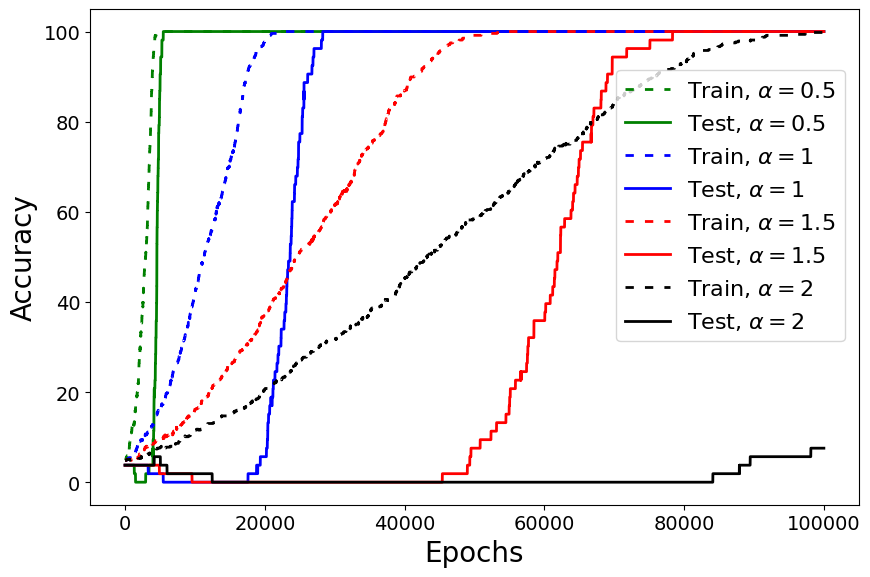

In [8]:
colors = ['g', 'b', 'r', 'black']
plt.figure(figsize=(9, 6))
plt.rcParams.update({'font.size': 14})

plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)

for i in range(len(trs)):
    plt.plot(range(epochs), trs[i], color=colors[i], label=rf'Train, $\alpha={scales[i]}$', linestyle='--', linewidth=2.0, dashes=(3, 4))
    plt.plot(range(epochs), tls[i], color=colors[i], label=rf'Test, $\alpha={scales[i]}$', linewidth=2.0)

plt.legend(bbox_to_anchor=(0.67, 0.9), fontsize=16)
plt.tight_layout()
plt.show()

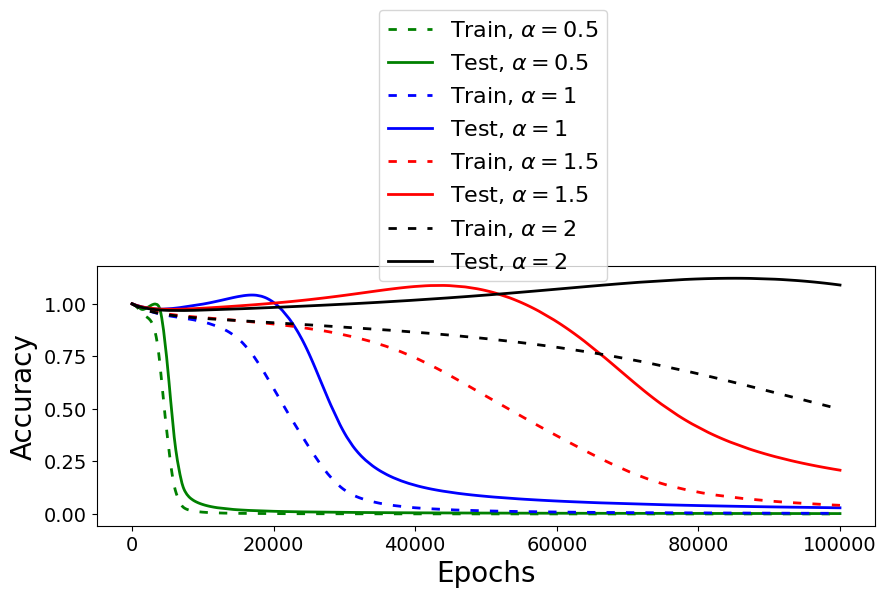

In [9]:
colors = ['g', 'b', 'r', 'black']
plt.figure(figsize=(9, 6))
plt.rcParams.update({'font.size': 14})

plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Accuracy', fontsize=20)

for i in range(len(trs_precond)):
    plt.plot(range(len(trs[i])), np.array(tr_losses[i]) / tr_losses[i][0], color=colors[i], label=rf'Train, $\alpha={scales[i]}$', linestyle='--', linewidth=2.0, dashes=(3, 4))
    plt.plot(range(len(trs[i])), np.array(te_losses[i]) / te_losses[i][0], color=colors[i], label=rf'Test, $\alpha={scales[i]}$', linewidth=2.0)

plt.legend(bbox_to_anchor=(0.67, 0.9), fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
import matplotlib.patches as patches

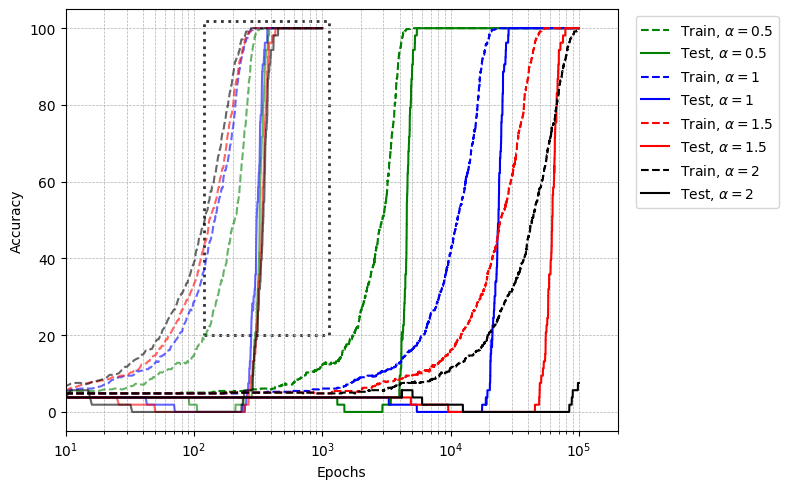

In [13]:
colors = ['g', 'b', 'r', 'black']
plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.size': 10})
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

for i in range(len(trs)):
    plt.semilogx(range(1, len(trs[i])+1), trs[i], color=colors[i], label=rf'Train, $\alpha={scales[i]}$', linestyle='--')
    plt.semilogx(range(1, len(trs[i])+1), tls[i], color=colors[i], label=rf'Test, $\alpha={scales[i]}$')
    # plt.semilogx(range(1, len(trs_precond[i])+1), trs_precond[i], color=colors[i], label=rf'Train, $\alpha={scales[i]}$', linestyle='--', marker='o', markevery=0.1)
    # plt.semilogx(range(1, len(trs_precond[i])+1), tls_precond[i], color=colors[i], label=rf'Test, $\alpha={scales[i]}$', marker='o', markevery=0.1)
    plt.semilogx(range(1, len(trs_precond[i])+1), trs_precond[i], color=colors[i], linestyle='--', alpha=.6)
    plt.semilogx(range(1, len(trs_precond[i])+1), tls_precond[i], color=colors[i], alpha=.6)
plt.xlim((1e1, 2e5))

ax = plt.gca()
rect = patches.Rectangle(
    (120, 20), 1000, 82, linewidth=2, edgecolor='black', facecolor='none', linestyle='dotted', alpha=.8
)
ax.add_patch(rect)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout()
plt.show()

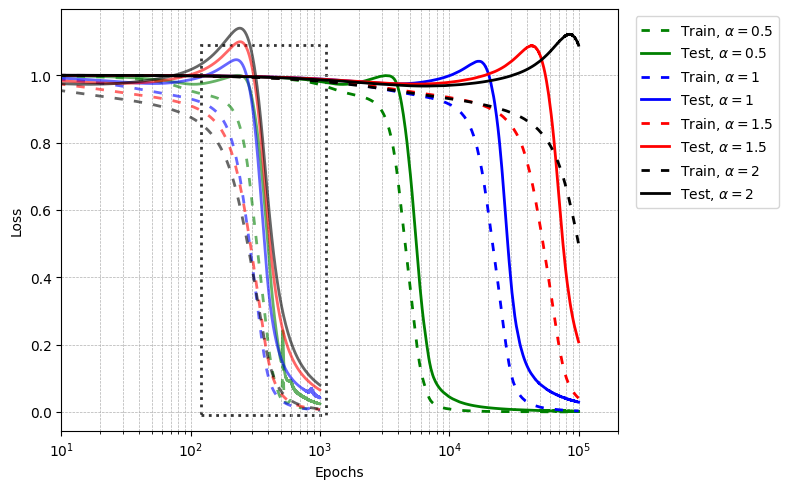

In [14]:
plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.size': 10})
plt.xlabel('Epochs')
plt.ylabel('Loss')


for i in range(len(trs_precond)):
    plt.semilogx(range(len(trs[i])), np.array(tr_losses[i]) / tr_losses[i][0], color=colors[i], label=rf'Train, $\alpha={scales[i]}$', linestyle='--', linewidth=2.0, dashes=(3, 4))
    plt.semilogx(range(len(trs[i])), np.array(te_losses[i]) / te_losses[i][0], color=colors[i], label=rf'Test, $\alpha={scales[i]}$', linewidth=2.0)
    plt.semilogx(range(len(trs_precond[i])), np.array(tr_losses_precond[i]) / tr_losses_precond[i][0], color=colors[i], linestyle='--', linewidth=2.0, dashes=(3, 4), alpha=.6)
    plt.semilogx(range(len(trs_precond[i])), np.array(te_losses_precond[i]) / te_losses_precond[i][0], color=colors[i], linewidth=2.0, alpha=.6)

plt.xlim((1e1, 2e5))

ax = plt.gca()
rect = patches.Rectangle(
    (120, -.01), 1000, 1.1, linewidth=2, edgecolor='black', facecolor='none', linestyle='dotted', alpha=.8
)
ax.add_patch(rect)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout()
plt.show()

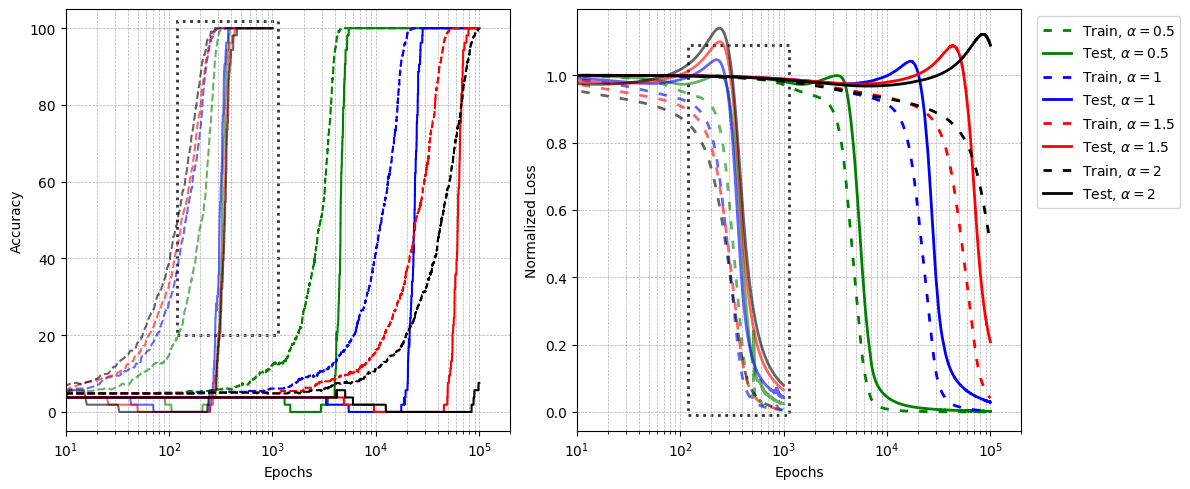

In [20]:

# Assuming trs, tls, trs_precond, tls_precond, tr_losses, te_losses, tr_losses_precond, te_losses_precond, scales are defined

colors = ['g', 'b', 'r', 'black']

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.rcParams.update({'font.size': 10})

# First plot: Accuracy
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')

for i in range(len(trs)):
    ax1.semilogx(range(1, len(trs[i]) + 1), trs[i], color=colors[i], label=rf'Train, $\alpha={scales[i]}$', linestyle='--')
    ax1.semilogx(range(1, len(trs[i]) + 1), tls[i], color=colors[i], label=rf'Test, $\alpha={scales[i]}$')
    ax1.semilogx(range(1, len(trs_precond[i]) + 1), trs_precond[i], color=colors[i], linestyle='--', alpha=.6)
    ax1.semilogx(range(1, len(trs_precond[i]) + 1), tls_precond[i], color=colors[i], alpha=.6)

ax1.set_xlim((1e1, 2e5))
rect1 = patches.Rectangle((120, 20), 1000, 82, linewidth=2, edgecolor='black', facecolor='none', linestyle='dotted', alpha=.8)
ax1.add_patch(rect1)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
# ax1.legend(bbox_to_anchor=(1.02, 1), fontsize=10)

# Second plot: Loss
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Normalized Loss')

for i in range(len(trs_precond)):
    ax2.semilogx(range(len(trs[i])), np.array(tr_losses[i]) / tr_losses[i][0], color=colors[i], label=rf'Train, $\alpha={scales[i]}$', linestyle='--', linewidth=2.0, dashes=(3, 4))
    ax2.semilogx(range(len(trs[i])), np.array(te_losses[i]) / te_losses[i][0], color=colors[i], label=rf'Test, $\alpha={scales[i]}$', linewidth=2.0)
    ax2.semilogx(range(len(trs_precond[i])), np.array(tr_losses_precond[i]) / tr_losses_precond[i][0], color=colors[i], linestyle='--', linewidth=2.0, dashes=(3, 4), alpha=.6)
    ax2.semilogx(range(len(trs_precond[i])), np.array(te_losses_precond[i]) / te_losses_precond[i][0], color=colors[i], linewidth=2.0, alpha=.6)

ax2.set_xlim((1e1, 2e5))
rect2 = patches.Rectangle((120, -.01), 1000, 1.1, linewidth=2, edgecolor='black', facecolor='none', linestyle='dotted', alpha=.8)
ax2.add_patch(rect2)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.legend(bbox_to_anchor=(1.02, 1), fontsize=10)

# Adjust layout
plt.tight_layout()
plt.savefig('grokking_modulo.png')
plt.show()
